# Study of the network of Twitch gamers

OULD AKLOUCHE Sarah, PINATEL Olivier

## Imports

In [3]:
%pip install networkx
%pip install networkx python-louvain pandas
%pip install igraph leidenalg pandas
%pip install igraph

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [12]:
import networkx as nx
import pandas as pd
import numpy as np
import community as community_louvain
#import igraph as ig
#import leidenalg as la
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import normalized_mutual_info_score

## Reading the data

In [13]:
# Lire les données
df=pd.read_csv("data/large_twitch_features.csv")
df2=pd.read_csv("data/large_twitch_edges.csv")

## Descriptive statistics

In [3]:
df.head()

,views,mature,life_time,created_at,updated_at,numeric_id,dead_account,language,affiliate
0,7879,1,969,2016-02-16,2018-10-12,0,0,EN,1
1,500,0,2699,2011-05-19,2018-10-08,1,0,EN,0
2,382502,1,3149,2010-02-27,2018-10-12,2,0,EN,1
3,386,0,1344,2015-01-26,2018-10-01,3,0,EN,0
4,2486,0,1784,2013-11-22,2018-10-11,4,0,EN,0


In [5]:
len(df)

168114

In [6]:
mapping_m = {0: "Not mature", 1: "Mature"}
df["mature_cl"] = df["mature"].map(mapping_m)
mapping_a = {0: "Not affiliate", 1: "Affiliate"}
df["affiliate_cl"] = df["affiliate"].map(mapping_a)
df.head()

,views,mature,life_time,created_at,updated_at,numeric_id,dead_account,language,affiliate,mature_cl,affiliate_cl
0,7879,1,969,2016-02-16,2018-10-12,0,0,EN,1,Mature,Affiliate
1,500,0,2699,2011-05-19,2018-10-08,1,0,EN,0,Not mature,Not affiliate
2,382502,1,3149,2010-02-27,2018-10-12,2,0,EN,1,Mature,Affiliate
3,386,0,1344,2015-01-26,2018-10-01,3,0,EN,0,Not mature,Not affiliate
4,2486,0,1784,2013-11-22,2018-10-11,4,0,EN,0,Not mature,Not affiliate


In [7]:
df.groupby("language")["views"].describe()

,count,mean,std,min,25%,50%,75%,max
language,,,,,,,,
CS,576.0,287614.647569,1.495492e+06,103.0,3967.25,13779.0,46653.75,19445384.0
DA,503.0,106778.586481,4.768160e+05,217.0,3335.00,8599.0,29241.50,5139341.0
DE,9428.0,146274.760819,1.663765e+06,25.0,2167.75,6175.5,19503.25,100394785.0
EN,124411.0,162461.082814,3.367933e+06,0.0,1233.00,3509.0,11471.00,368912220.0
ES,5699.0,125785.250219,1.271431e+06,2.0,1515.50,4440.0,15577.00,63285497.0
FI,652.0,72028.090491,3.019135e+05,128.0,2538.00,7511.0,27296.50,3994591.0
FR,6799.0,175994.915282,2.176433e+06,20.0,2064.50,6027.0,19639.50,108432615.0
HU,427.0,191377.112412,1.098021e+06,64.0,2585.00,7346.0,38530.50,17315463.0
IT,1230.0,163607.550407,1.482317e+06,18.0,1633.50,5023.0,18284.75,38793358.0


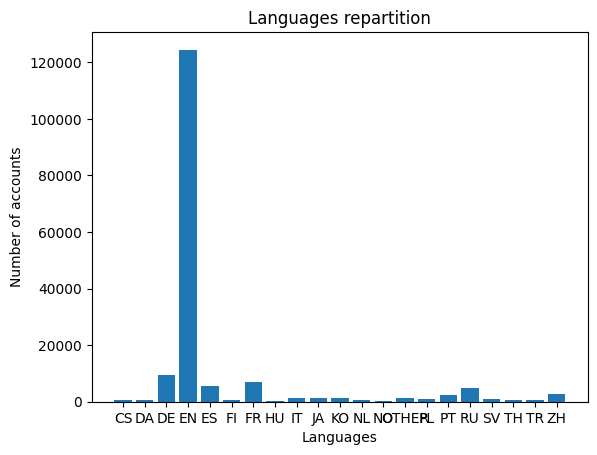

In [ ]:
counts = df["language"].value_counts().sort_index()

plt.bar(counts.index, counts.values)

plt.title("Languages repartition")
plt.xlabel("Languages")
plt.ylabel("Number of accounts")

#plt.savefig("Language repartition")
plt.show()

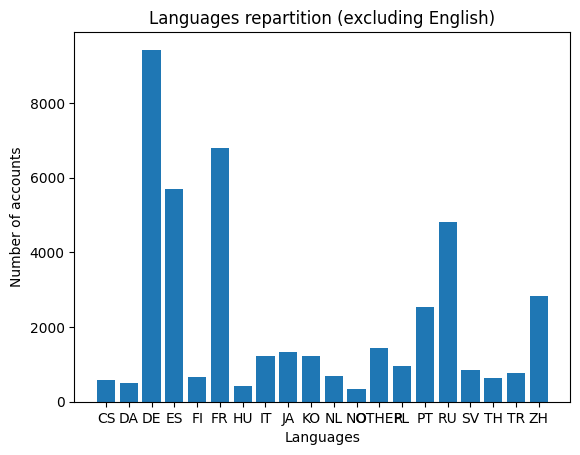

In [9]:
counts_no_english = df[df["language"] != "EN"]["language"].value_counts().sort_index()

plt.bar(counts_no_english.index, counts_no_english.values)

plt.title("Languages repartition (excluding English)")
plt.xlabel("Languages")
plt.ylabel("Number of accounts")

#plt.savefig("Language repartition (excluding English)")
plt.show()

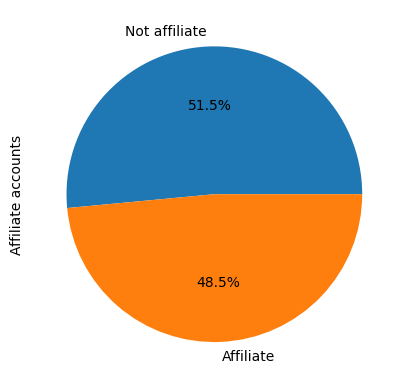

In [10]:
df["affiliate_cl"].value_counts().plot.pie(autopct='%1.1f%%')

plt.ylabel("Affiliate accounts")  
plt.show()

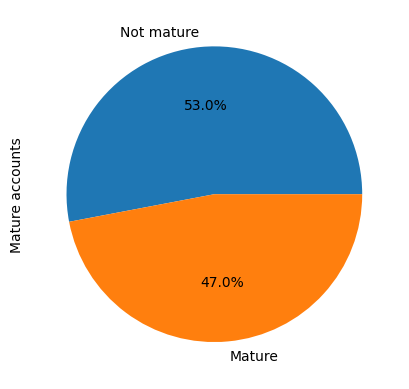

In [11]:
df["mature_cl"].value_counts().plot.pie(autopct='%1.1f%%')

plt.ylabel("Mature accounts")  
plt.show()

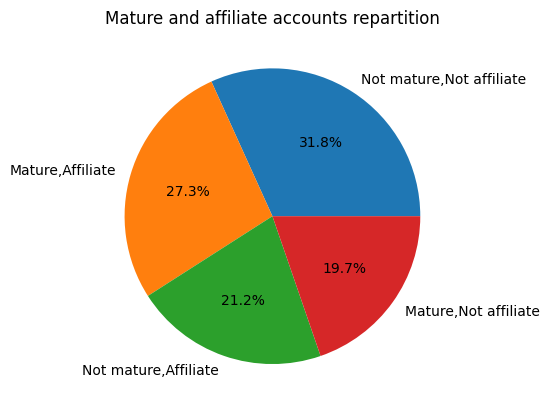

In [12]:
counts_m_a = df.value_counts(subset=['mature_cl', 'affiliate_cl'])

labels = [f"{idx[0]},{idx[1]}" for idx in counts_m_a.index]

plt.pie(counts_m_a, labels=labels, autopct='%1.1f%%')
plt.title("Mature and affiliate accounts repartition")
plt.show()

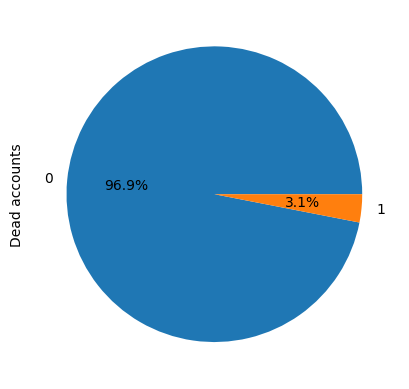

In [13]:
df["dead_account"].value_counts().plot.pie(autopct='%1.1f%%')

plt.ylabel("Dead accounts")  
plt.show()

## Studying the graph

In [116]:
# Création du graphe
G = nx.from_pandas_edgelist(df2, "numeric_id_1", "numeric_id_2", create_using=nx.Graph())

In [5]:
# Features disponibles
df

,views,mature,life_time,created_at,updated_at,numeric_id,dead_account,language,affiliate
0,7879,1,969,2016-02-16,2018-10-12,0,0,EN,1
1,500,0,2699,2011-05-19,2018-10-08,1,0,EN,0
2,382502,1,3149,2010-02-27,2018-10-12,2,0,EN,1
3,386,0,1344,2015-01-26,2018-10-01,3,0,EN,0
4,2486,0,1784,2013-11-22,2018-10-11,4,0,EN,0
...,...,...,...,...,...,...,...,...,...
168109,4965,0,810,2016-07-20,2018-10-08,168109,0,EN,0
168110,4128,1,2080,2013-01-31,2018-10-12,168110,0,EN,0
168111,3545,0,1797,2013-11-08,2018-10-10,168111,0,EN,1
168112,892736,1,2135,2012-12-07,2018-10-12,168112,0,EN,0


# Détection de communautés

## Label propagation

En premier, nous appliquons l'algorithme de Label propagation pour avoir une première idée de la structure possible du graphe.

In [6]:
# Tourne en 6 minutes
communities = nx.algorithms.community.label_propagation_communities(G)

partition_lpa = {}
for i, comm in enumerate(communities):
    for node in comm:
        partition_lpa[node] = i

In [8]:
df_nodes_lpa = pd.DataFrame(list(partition_lpa.items()), columns=["node", "community_lpa"])

In [9]:
df_nodes_lpa["community_lpa"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78])

In [10]:
df_nodes_lpa["community_lpa"].value_counts()

community_lpa
0     160091
2       3143
1       2580
6        898
5        633
       ...  
74         2
75         2
76         2
77         2
78         2
Name: count, Length: 79, dtype: int64

79 communautés, avec une communauté très majoritaire.

In [11]:
# On calcule la modularité afin de pouvoir comparer avec la méthode suivante
mod = community_louvain.modularity(partition_lpa, G)
print("Modularité Label Propagation:", mod)

Modularité Label Propagation: 0.03567630678997075


In [12]:
# Sauvegarder le dataframe de nodes
df_nodes_lpa.to_csv("communities/lpa.csv")

## Louvain

In [13]:
# Met 12 minutes à tourner
partition_louvain = community_louvain.best_partition(
    G,
    resolution=1.0,
    random_state=42
)

In [14]:
df_nodes_louvain = pd.DataFrame(list(partition_louvain.items()), columns=["node", "community"])

In [15]:
df_nodes_louvain["community"].value_counts()

community
3     47419
1     34678
0     24572
2     24146
11     8779
13     6219
5      5080
4      5016
8      4608
29     2010
9      1169
16      826
14      729
15      669
6       539
17      501
10      405
7       367
18      344
22        7
25        5
24        4
19        3
31        3
20        2
21        2
23        2
26        2
27        2
28        2
30        2
12        2
Name: count, dtype: int64

In [16]:
df_nodes_louvain["community"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 29, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 30, 31, 12])

31 communautés, dont 19 avec plus de 10 utilisateurs.

In [17]:
mod = community_louvain.modularity(partition_louvain, G)
print("Modularité:", mod)

Modularité: 0.4179872537787052


Bien meilleure modularité que label propagation, le graphe semble effectivement avoir une structure en communauté exploitable, mais celles ci sont détectables au niveau global et pas vraiment au niveau local.

In [18]:
# Sauvegarder le dataframe de nodes
df_nodes_louvain.to_csv("communities/louvain.csv")

## Leiden (mais n'utilise pas networkx donc à voir si on garde ou pas)

In [19]:
g = ig.Graph.TupleList(
    df2.itertuples(index=False), 
    directed=False
)

In [20]:
# 2 minutes
partition_leiden = la.find_partition(
    g,
    la.RBConfigurationVertexPartition,
    resolution_parameter=1.0
)

In [21]:
df_nodes_leiden = pd.DataFrame({
    "node": g.vs["name"],
    "community_leiden": partition_leiden.membership
})


In [22]:
df_nodes_leiden["community_leiden"].unique()

array([ 1,  0,  5,  2,  3,  4,  8,  9, 16, 10, 12,  6, 11,  7, 14, 15, 13,
       17, 18, 19])

In [23]:
df_nodes_leiden["community_leiden"].value_counts()

community_leiden
0     37621
1     23660
2     19870
3     18391
4     16097
5     15576
6      8830
7      6225
8      5112
9      5099
10     4624
11     2185
12     1166
13      846
14      734
15      672
16      550
17      510
18      343
19        3
Name: count, dtype: int64

24 communautés, 19 avec plus de 300 utilisateurs.

In [24]:
mod = g.modularity(partition_leiden.membership)
print("Modularité Leiden:", mod)

Modularité Leiden: 0.42221641588962905


In [25]:
# Sauvegarder le dataframe de nodes
df_nodes_leiden.to_csv("communities/leiden.csv")

# Comparaison à l'aide de la Mutual Entropy (Normalized Mutual Information) - > pour le moment pose problème

On utilise la NMI pour comparer ces trois algorithmes (a priori LPA est déjà éliminé), on les compare 2 à 2, donc on va obtenir une matrice de similarité. 

In [26]:
def partition_to_labels(partition, nodes):
    label_dict = {}
    for i, community in enumerate(partition):
        for node in community:
            label_dict[node] = i
    return [label_dict[node] for node in nodes]

def dict_to_labels(partition_dict, nodes):
    return [partition_dict[node] for node in nodes]

In [36]:
df_communautes = df_nodes_louvain.merge(df_nodes_leiden, on="node")
df_communautes = df_communautes.merge(df_nodes_lpa, on="node")

In [37]:
nmi_louvain_leiden = normalized_mutual_info_score(df_communautes["community"], df_communautes["community_leiden"])
nmi_louvain_lpa = normalized_mutual_info_score(df_communautes["community"], df_communautes["community_lpa"])
nmi_leiden_lpa = normalized_mutual_info_score(df_communautes["community_leiden"], df_communautes["community_lpa"])

In [38]:
print("Score de NMI entre Louvain et Leiden : " + str(nmi_louvain_leiden))
print("Score de NMI entre Louvain et Label propagation : " + str(nmi_louvain_lpa))
print("Score de NMI entre Leiden et Label propagation : " + str(nmi_leiden_lpa))

Score de NMI entre Louvain et Leiden : 0.6282305798380243
Score de NMI entre Louvain et Label propagation : 0.17672008549483112
Score de NMI entre Leiden et Label propagation : 0.15704615415837855


# Langues des communautés obtenues par Leiden

Dans cette section, on regarde dans quelle mesure les communautés obtenues sont dominées par une langue.

In [14]:
df_nodes_leiden=pd.read_csv("communities/leiden.csv")

In [15]:
df_nodes_leiden=df_nodes_leiden.rename(columns={"node":"numeric_id"})

In [16]:
df_nodes_leiden=df_nodes_leiden.merge(df, on="numeric_id", how="left")

In [17]:
# Création d'un dataframe stockant des informations sur les communautés
df_langues=pd.DataFrame({"nb users":[], "langue majoritaire":[], "nb langue majoritaire":[], "proportion langue majoritaire":[], "recall langue majoritaire":[]})
df_langues["langue majoritaire"]=df_langues["langue majoritaire"].astype(str)

In [18]:
for i in range(df_nodes_leiden["community_leiden"].nunique()):
    df_com=df_nodes_leiden[df_nodes_leiden["community_leiden"]==i]
    df_langues.loc[i, "nb users"]=len(df_com)
    langue_maj=df_com["language"].value_counts().idxmax()
    df_langues.loc[i, "langue majoritaire"]=langue_maj
    df_langues.loc[i, "nb langue majoritaire"]=df_com["language"].value_counts()[langue_maj]
    df_langues.loc[i, "proportion langue majoritaire"]=df_langues.loc[i, "nb langue majoritaire"]/len(df_com)
    df_langues.loc[i, "recall langue majoritaire"]=df_langues.loc[i, "nb langue majoritaire"]/len(df_nodes_leiden[df_nodes_leiden["language"]==langue_maj])

In [19]:
df_langues

,nb users,langue majoritaire,nb langue majoritaire,proportion langue majoritaire,recall langue majoritaire
0,37621.0,EN,34347.0,0.912974,0.276077
1,23660.0,EN,23222.0,0.981488,0.186656
2,19870.0,EN,18054.0,0.908606,0.145116
3,18391.0,EN,17869.0,0.971617,0.143629
4,16097.0,EN,15165.0,0.942101,0.121894
5,15576.0,EN,14098.0,0.905110,0.113318
6,8830.0,DE,8378.0,0.948811,0.888630
7,6225.0,FR,5985.0,0.961446,0.880277
8,5112.0,ZH,2736.0,0.535211,0.967468
9,5099.0,ES,4876.0,0.956266,0.855589


In [20]:
# Étude spécifique de la communauté chinoise
df_nodes_leiden[df_nodes_leiden["community_leiden"]==8]["language"].value_counts()

language
ZH       2736
KO       1108
JA        924
EN        295
OTHER      31
ES          5
SV          2
DE          2
FR          2
RU          2
FI          1
PT          1
TH          1
TR          1
NL          1
Name: count, dtype: int64

In [132]:
df_nodes_leiden["language"].nunique()

21

In [133]:
df_langues["langue majoritaire"].nunique()

14

On constate que les utilisateurs anglophones de Twitch sont répartis dans 7 communautés. Les autres communautés sont principalement concentrées autour d'un language, à l'exception de la communauté chinoise (8) qui comprend aussi beaucoup d'utilisateurs coréens et japonais. Pour chacune de ces communautés non-anglophones, la majorité des utilisateurs parlant la langue se trouvent dans la communauté (indicateur "recall langue majoritaire"). Enfin, on constate que certaines langues n'ont pas de communauté propre.

On peut conclure que comparer les communautés obtenues avec Leiden revient à comparer des communautés linguistiques.

# Étude des communautés linguistiques

Dans cette section, on étudie quelques propriétés des communautés : force, densité, coefficient de clustering, distribution des degrés. On compare ces propriétés avec un modèle de configuration pour savoir si elles sont dues à l'hétérogénéité des degrés.

In [63]:
df_nb_edges = pd.DataFrame({"numeric_id": [], "community_leiden": []})

for node in tqdm(df_nodes_leiden["numeric_id"]):
    edges = df2[(df2["numeric_id_1"] == node) | (df2["numeric_id_2"] == node)]
    set_edges = set(edges["numeric_id_1"].tolist() + edges["numeric_id_2"].tolist())
    nodes = df_nodes_leiden[df_nodes_leiden["numeric_id"].isin(set_edges)]
    
    community = df_nodes_leiden.loc[df_nodes_leiden["numeric_id"] == node, "community_leiden"].values[0]
    
    counts = nodes["community_leiden"].value_counts().to_dict()
    counts["numeric_id"] = node
    counts["community_leiden"] = community
    
    df_nb_edges = pd.concat([df_nb_edges, pd.DataFrame([counts])], ignore_index=True)

# Remplir les NaN par 0
df_nb_edges = df_nb_edges.fillna(0)

100%|███████████████████████████████████████| 168114/168114 [1:29:18<00:00, 31.38it/s]


In [64]:
df_nb_edges.to_csv("communities/counts_leiden.csv")

In [71]:
df_langues["strong"]=False
df_langues["weak"]=False

In [112]:
for i in df_langues.index:
    df_com=df_nb_edges[df_nb_edges["community_leiden"]==i]
    maximum=df_com.drop(["numeric_id", "community_leiden"], axis=1).max().idxmax()
    if maximum==i:
        df_langues.loc[i, "strong"]=True
    sum_nodes=df_com.drop(["numeric_id", "community_leiden"], axis=1).sum()
    if sum_nodes.idxmax()==i:
        df_langues.loc[i, "weak"]=True

On constate que toutes les communautés sont fortes.

On peut calculer la densité et le clustering coefficient des communautés pour les comparer.

In [21]:
for i in tqdm(df_langues.index):
    df_com=df_nodes_leiden[df_nodes_leiden["community_leiden"]==i]
    edges=df2[(df2["numeric_id_1"].isin(df_com["numeric_id"])) & (df2["numeric_id_1"].isin(df_com["numeric_id"]))]
    graph_com=nx.from_pandas_edgelist(edges, "numeric_id_1", "numeric_id_2", create_using=nx.Graph())
    df_langues.loc[i, "densité"]=nx.density(graph_com)
    df_langues.loc[i, "clustering coefficient"]=nx.average_clustering(graph_com)

100%|██████████| 20/20 [19:11<00:00, 57.59s/it]  


In [22]:
df_langues.to_csv("communities/df_langues.csv")

In [23]:
df_langues

,nb users,langue majoritaire,nb langue majoritaire,proportion langue majoritaire,recall langue majoritaire,densité,clustering coefficient
0,37621.0,EN,34347.0,0.912974,0.276077,0.000184,0.241572
1,23660.0,EN,23222.0,0.981488,0.186656,0.000193,0.165474
2,19870.0,EN,18054.0,0.908606,0.145116,0.000131,0.187250
3,18391.0,EN,17869.0,0.971617,0.143629,0.000195,0.100018
4,16097.0,EN,15165.0,0.942101,0.121894,0.000119,0.144298
5,15576.0,EN,14098.0,0.905110,0.113318,0.000277,0.205937
6,8830.0,DE,8378.0,0.948811,0.888630,0.000535,0.110349
7,6225.0,FR,5985.0,0.961446,0.880277,0.000739,0.115340
8,5112.0,ZH,2736.0,0.535211,0.967468,0.000858,0.154043
9,5099.0,ES,4876.0,0.956266,0.855589,0.001303,0.132861


On peut aussi représenter la distribution des degrés.

In [9]:
def logBinning(degreeList,nbin):
    kmin=min(degreeList)
    kmax=max(degreeList)
    logBins = np.logspace(np.log10(kmin), np.log10(kmax),num=nbin)
    logBinDensity, binedges = np.histogram(degreeList, bins=logBins, density=True)
    logBins = np.delete(logBins, -1)
    return logBinDensity, logBins

100%|█████████████████████████████████████████████████| 20/20 [01:20<00:00,  4.02s/it]


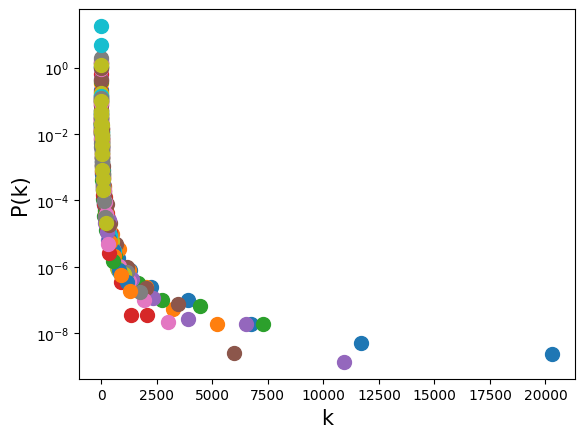

In [135]:
for i in tqdm(df_langues.index):
    df_com=df_nodes_leiden[df_nodes_leden["community_leiden"]==i]
    edges=df2[(df2["numeric_id_1"].isin(df_com["numeric_id"])) & (df2["numeric_id_1"].isin(df_com["numeric_id"]))]
    graph_com=nx.from_pandas_edgelist(edges, "numeric_id_1", "numeric_id_2", create_using=nx.Graph())
    k=[graph_com.degree(n) for n in graph_com.nodes()]
    y,x=logBinning(np.array(k),20)
    plt.semilogy(x,y,'o',markersize=10)
    plt.xlabel('k',size=15)
    plt.ylabel('P(k)',size=15)

plt.savefig("degree_distribution.png")

100%|█████████████████████████████████████████████████| 20/20 [00:52<00:00,  2.61s/it]


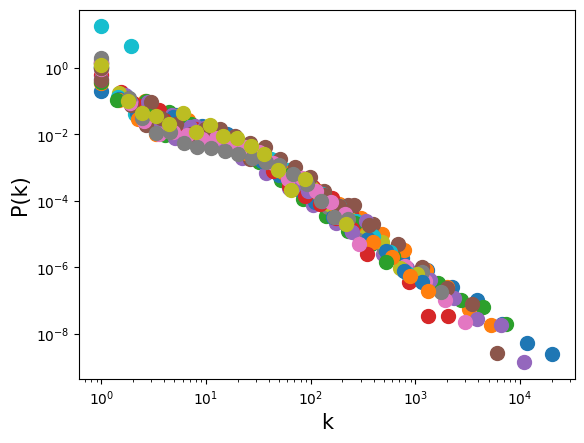

In [136]:
for i in tqdm(df_langues.index):
    df_com=df_nodes_leiden[df_nodes_leiden["community_leiden"]==i]
    edges=df2[(df2["numeric_id_1"].isin(df_com["numeric_id"])) & (df2["numeric_id_1"].isin(df_com["numeric_id"]))]
    graph_com=nx.from_pandas_edgelist(edges, "numeric_id_1", "numeric_id_2", create_using=nx.Graph())
    k=[graph_com.degree(n) for n in graph_com.nodes()]
    y,x=logBinning(np.array(k),20)
    plt.loglog(x,y,'o',markersize=10)
    plt.xlabel('k',size=15)
    plt.ylabel('P(k)',size=15)

plt.savefig("degree_distribution_loglog.png")

La distribution des degrés suit une loi de puissance pour toutes les communautés.

On compare ces propriétés à celles d'un modèle de configuration.

In [39]:
def analytical_expected_clustering(G):
    degrees = np.array([d for _, d in G.degree()])
    n = len(degrees)
    k_mean = degrees.mean()
    k2_mean = (degrees**2).mean()
    
    expected_C = ((k2_mean - k_mean)**2) / (k_mean**3 * n)
    return expected_C


In [45]:
for i in df_langues.index:
    df_com=df_nodes_leiden[df_nodes_leiden["community_leiden"]==i]
    edges=df2[(df2["numeric_id_1"].isin(df_com["numeric_id"])) & (df2["numeric_id_1"].isin(df_com["numeric_id"]))]
    graph_com=nx.from_pandas_edgelist(edges, "numeric_id_1", "numeric_id_2", create_using=nx.Graph())
    
    expected = analytical_expected_clustering(graph_com)
    df_langues.loc[i, "clustering coefficient config"]=expected
    df_langues.loc[i, "ratio"]= df_langues.loc[i, "clustering coefficient"]/df_langues.loc[i, "clustering coefficient config"]

In [46]:
df_langues

,nb users,langue majoritaire,nb langue majoritaire,proportion langue majoritaire,recall langue majoritaire,densité,clustering coefficient,clustering coefficient config,ratio
0,37621.0,EN,34347.0,0.912974,0.276077,0.000184,0.241572,2.022972,0.119414
1,23660.0,EN,23222.0,0.981488,0.186656,0.000193,0.165474,0.125554,1.317958
2,19870.0,EN,18054.0,0.908606,0.145116,0.000131,0.187250,1.166118,0.160575
3,18391.0,EN,17869.0,0.971617,0.143629,0.000195,0.100018,0.026252,3.809925
4,16097.0,EN,15165.0,0.942101,0.121894,0.000119,0.144298,1.736388,0.083103
5,15576.0,EN,14098.0,0.905110,0.113318,0.000277,0.205937,0.440807,0.467182
6,8830.0,DE,8378.0,0.948811,0.888630,0.000535,0.110349,0.252574,0.436898
7,6225.0,FR,5985.0,0.961446,0.880277,0.000739,0.115340,0.240105,0.480371
8,5112.0,ZH,2736.0,0.535211,0.967468,0.000858,0.154043,0.160196,0.961590
9,5099.0,ES,4876.0,0.956266,0.855589,0.001303,0.132861,0.117747,1.128358


In [48]:
df_langues.to_csv("communities/df_langues.csv")